From https://eloy.readthedocs.io/en/latest/photometry/

In [38]:

from astropy.io import fits
from dateutil import parser
from glob import glob

reference_file = "output/stack_image.fits"

#images = glob("data/*.fits.fz")
images = glob("/home/adamarthurryan/Desktop/baron obs/3c371/3c371_20260615_baron_ip/*.fits.fz")

target_name = "3C 371"

# get observation time from FITS header (SCI extension)
def observation_time(file):

    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    return parser.parse(date_str)


# order by observation time
images = sorted(images, key=lambda file: observation_time(file))


In [ ]:
#images=images[0:10]


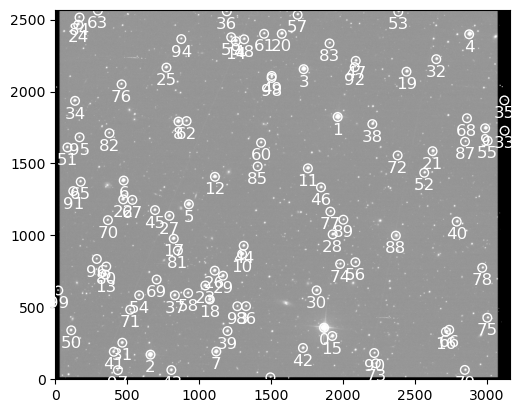

In [39]:
# calibration sequence

import numpy as np
import matplotlib.pyplot as plt
from eloy import alignment, viz


from eloy import psf, detection, utils

trim = 10
n_stars_align = 12


def calibration_sequence(file):
    # getting data
    data = fits.getdata(file)
    header = fits.getheader(file)

    # trimming
    calibrated_data = data[trim:-trim, trim:-trim]
#    calibrated_data = data

    # detection
    regions = detection.stars_detection(calibrated_data)
    # stars coords and cutouts
    region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])
    cutouts = utils.cutout(calibrated_data, region_coords, (50, 50))

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    epsf = np.nanmedian(cutouts_normalized, 0)
    psf_params = psf.fit_gaussian(epsf)
    fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
        [psf_params["sigma_x"], psf_params["sigma_y"]]
    )

    del (
        cutouts_normalized,
        data,
        regions,
        cutouts,
        epsf,
        header,
    )

    return calibrated_data, region_coords, fwhm


# and create a calibration sequence from the reference image

ref_data, ref_coords, ref_fwhm = calibration_sequence(reference_file)
ref_reference = alignment.twirl_reference(ref_coords[0:n_stars_align])

ref_header = fits.getheader(reference_file)

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(*ref_coords.T, color="w", label=True, ms=30)


In [40]:
# now do the photometry sequence for all images

from tqdm.auto import tqdm
from skimage.transform import AffineTransform, warp
from eloy.ballet import Ballet
from astropy.time import Time
from collections import defaultdict
from eloy import centroid, photometry

n_stars = 100
relative_apertures_radii = np.linspace(0.1, 5, 40)
cnn = Ballet()

data = defaultdict(list)

for file in tqdm(images):
    calibrated_data, coords, fwhm = calibration_sequence(file)

    # alignment
    R = alignment.rotation_matrix(coords[0:n_stars_align], ref_coords, ref_reference)
    transform = AffineTransform(R)#.inverse
    aligned_coords = transform(ref_coords)[0:n_stars]
    dx, dy = np.median(ref_coords[0:n_stars] - aligned_coords, 0)

    # centroiding
    centroid_coords = centroid.ballet_centroid(calibrated_data, aligned_coords, cnn)
    # aperture photometry
    apertures_radii = relative_apertures_radii * fwhm
    flux = photometry.aperture_photometry(
        calibrated_data, centroid_coords, apertures_radii
    )
    # annulus background correction
    annulus_radii = np.max(apertures_radii), 8 * fwhm
    aperture_area = np.pi * apertures_radii**2
    bkg = photometry.annulus_sigma_clip_median(
        calibrated_data, centroid_coords, *annulus_radii
    )
    bkg = bkg[:, None] * aperture_area[None, :]

    # getting data
    header = fits.open(file)[0].header
    data["bkg"].append(bkg)
    data["fluxes"].append(flux)
    data["fwhm"].append(fwhm)
    
    sci_header = fits.getheader(file, extname='sci')
    date_str = sci_header["DATE-OBS"]
    jd = Time(parser.parse(date_str)).jd


    #jd = Time(parser.parse(header["DATE-OBS"])).jd
    data["time"].append(jd)
    data["dx"].append(dx)
    data["dy"].append(dy)


for k, v in data.items():
    data[k] = np.array(v)


  0%|          | 0/97 [00:00<?, ?it/s]

In [7]:
data["fluxes"].shape

(10, 100, 40)

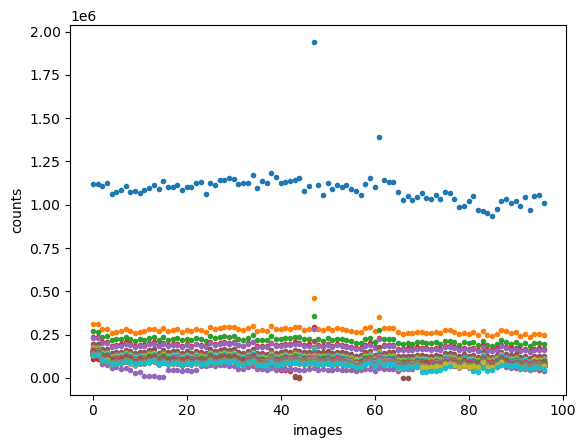

In [41]:
import matplotlib.pyplot as plt

#plot some random photometry data
for i in range(n_stars):
    plt.plot(data["fluxes"][:, i, 20], ".")
plt.xlabel("images")
_ = plt.ylabel("counts")


Target index is 88
[2368.06521739  998.06521739]
<SkyCoord (ICRS): (ra, dec) in deg
    (271.7157511, 69.82320714)>
<SkyCoord (ICRS): (ra, dec) in deg
    (271.71116788, 69.82447489)>


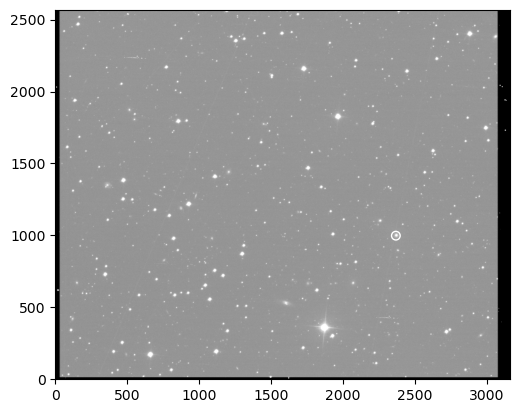

In [42]:
# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform ref_coords to skycoords
wcs = WCS(ref_header)
centroid_radec = wcs.pixel_to_world(*ref_coords.T)

mast = Mast()
target_radec = mast.resolve_object(target_name)
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{ref_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

plt.imshow(viz.z_scale(ref_data), cmap="Greys_r", origin="lower")
viz.plot_marks(ref_coords[target_index][0],ref_coords[target_index][1], color="w", ms=30)

target = ref_coords[target_index]


In [44]:
from eloy import flux

def auto_diff_1d(fluxes, i=None):
    # Normalize by each star's own mean, as in `diff`/`weights`.
    dfluxes = fluxes / np.expand_dims(np.nanmean(fluxes, -1), -1)
    # Continuous Broeg weights for every star (2D (star, flux) input only,
    # see `weights`'s Notes).
    w = flux.weights(dfluxes)

    if i is not None:
        # Rank comparison-star candidates from most to least trustworthy
        # (descending Broeg weight).
        idxs = np.argsort(w)[::-1]
        # Callable estimating white noise as the mean standard deviation
        # within short bins, robust to slower (red) residual trends.
        white_noise = utils.binned_nanstd(dfluxes)
        last_white_noise = 1e10  # sentinel: worse than any real value

        def best_weights(j):
            # Keep only the top-j ranked comparison stars (by weight),
            # zeroing out the rest, and always exclude the target star
            # itself from its own comparison ensemble.
            _w = w.copy()
            _w[idxs[j::]] = 0.0
            _w[i] = 0.0
            return _w

        # Greedily grow the comparison ensemble, best star first, stopping
        # as soon as adding the next star stops helping the target's noise.
        for j in range(w.shape[-1]):
            _w = best_weights(j)
            _df = flux.diff(dfluxes, _w)
            # `_df` carries the extra leading singleton axis described in
            # `diff`'s Notes; select the target star's white noise and
            # unwrap that axis with the trailing [0].
            _white_noise = np.take(white_noise(_df), i, axis=-1)[0]
            if not np.isfinite(_white_noise):
                # Happens e.g. for j == 0 when no comparison star is
                # included yet (division by a degenerate/zero ensemble).
                continue
            if _white_noise < last_white_noise:
                # Still improving: keep growing the ensemble.
                last_white_noise = _white_noise
            else:
                # Adding this (lower-ranked, noisier) comparison star made
                # things worse: stop here, the previous count was better.
                break

        # Rebuild the weights using the best ensemble size found (one step
        # back from the count that first failed to improve, or from the
        # count that stopped the loop early).
        w = best_weights(j - 1)

    # Final differential fluxes computed with the (possibly trimmed)
    # weights; reshape guards against the extra singleton axis from `diff`.
    df = flux.diff(dfluxes, w)

    return df.reshape(fluxes.shape), w



# we remove the background from the annulus aperture
fluxes = (data["fluxes"] - data["bkg"]).T
flux1d = fluxes[25]

display(flux1d.shape)
diff, weights = auto_diff_1d(flux1d, target_index)
diff


(100, 97)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 97))

In [43]:
# "In order to perform differential photometry eloy implements the Broeg 2005 algorithm.""

from eloy import flux

# we remove the background from the annulus aperture
fluxes = (data["fluxes"] - data["bkg"]).T

display(fluxes.shape)
'''
# and perform different photometry
diffs, weights = flux.auto_diff(fluxes, target_index)

# finally we find the 'optimal' aperture for our target
best_aperture = flux.optimal_flux(diffs[:, target_index])
diff = diffs[best_aperture, target_index]
'''

diffs, weights = flux.auto_diff_1d(fluxes[20], target_index)
diff=diffs[target_index]
best_aperture = 2.5
display(diff)

(40, 100, 97)

/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/eloy/flux.py:97: RuntimeWarning: invalid value encountered in divide
  artificial_light_curve = (sub @ weighted_fluxes) / np.expand_dims(
/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/eloy/utils.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan])

In [24]:
display(data["time"])
utils.index_binning(data["time"], 0.005)

array([2461207.69516485, 2461207.69561022, 2461207.69609491,
       2461207.69654102, 2461207.69700623, 2461207.69747038,
       2461207.69796122, 2461207.69847969, 2461207.69897935,
       2461207.69950573])

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]

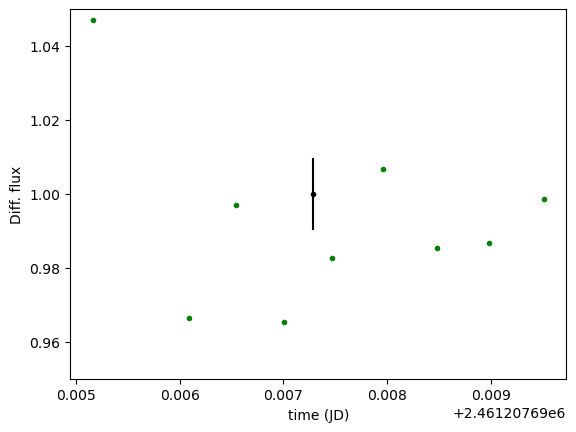

In [37]:
idxs = utils.index_binning(data["time"], 0.005)
binned_time = [data["time"][i].mean() for i in idxs]
binned_diff = [diff[i].mean() for i in idxs]
binned_error = [diff[i].std() / np.sqrt(len(i)) for i in idxs]


#plt.plot(data["time"], diffs[best_aperture, target_index, :], ".", c="0.8")
plt.plot(data["time"], diff, ".", c="g")
plt.errorbar(binned_time, binned_diff, yerr=binned_error, fmt=".", c="k")
plt.ylim(0.95, 1.05)
plt.xlabel("time (JD)")
_ = plt.ylabel("Diff. flux")


In [11]:
print(fluxes)

[[[2.01548032e+02 2.91356146e+02 3.26253933e+02 ... 1.06209936e+02
   8.36009626e+01 3.51414045e+01]
  [2.61658236e+04 2.66586785e+04 2.78549132e+04 ... 1.16858483e+04
   9.09765589e+03 1.15868706e+04]
  [2.06598572e+04 2.38102108e+04 2.58784053e+04 ... 8.02521867e+03
   8.98575499e+03 8.97590951e+03]
  ...
  [7.21362125e+02 6.76117808e+02 5.91318109e+02 ... 2.85116055e+02
   2.79342044e+02 3.07277618e+02]
  [5.57198036e+02 6.50311698e+02 7.30990315e+02 ... 2.26089384e+02
   2.18143014e+02 2.07964197e+02]
  [6.26940750e+02 5.16238481e+02 5.59218033e+02 ... 2.54284112e+02
   2.40822184e+02 2.67589290e+02]]

 [[1.16945435e+03 1.49424297e+03 1.75811944e+03 ... 5.29745204e+02
   4.17479422e+02 1.58020625e+02]
  [1.30829224e+05 1.22422454e+05 1.37252500e+05 ... 5.01066437e+04
   4.74203263e+04 5.10454887e+04]
  [1.02977459e+05 1.13511324e+05 1.25646064e+05 ... 4.08920139e+04
   4.69632406e+04 4.77961681e+04]
  ...
  [3.41011937e+03 3.35791160e+03 2.92929518e+03 ... 1.31393916e+03
   1.29428